# Plotting Time Series Models

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [87]:
# set folder with data
path = '../results/'
# get all files in the folder
all_files = glob.glob(path + "*.csv")

In [88]:
# filter the files that contain "covid"
covid_files = [f for f in all_files if 'covid' in f]
# filter the files that contain "epidemics"
epidemics_files = [f for f in all_files if 'epidemics' in f]

In [89]:
# get the original data
df_covid = pd.read_csv('../Data/silver/covid_data_weekly.csv')  

In [90]:
df_covid.head()

,country,date,new_cases,cases
0,Brazil,1/20/2020,0,0
1,Brazil,1/27/2020,0,0
2,Brazil,2/3/2020,0,0
3,Brazil,2/10/2020,0,0
4,Brazil,2/17/2020,0,0


In [91]:
nrow_dict = {}
for country in df_covid['country'].unique():
    df_temp = df_covid[df_covid['country'] == country]
    nrow_dict[country] = len(df_temp)

In [92]:
nrow_dict

{'Brazil': 164,
 'Chile': 164,
 'Colombia': 164,
 'Dominican Republic': 164,
 'Germany': 164,
 'Italy': 164,
 'Mexico': 164,
 'Panama': 164,
 'US': 164,
 'Uruguay': 164}

In [93]:
from functools import reduce

# -------------------------------------------------------------------
# 1.  Load raw CSVs
# -------------------------------------------------------------------
df_dengue    = pd.read_csv('../Data/silver/dengue_no_split.csv')
df_zika      = pd.read_csv('../Data/silver/zika.csv').drop(columns=['Unnamed: 0'])
df_chic      = pd.read_csv('../Data/silver/chicunguya.csv').drop(columns=['Unnamed: 0'])
df_varicela  = pd.read_csv('../Data/silver/varicela.csv')

# -------------------------------------------------------------------
# 2.  Helper that:  (i) parses DATE  (ii) builds cumulative + t-1 series
# -------------------------------------------------------------------
def prep(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    df = df.copy()
    df['DATE'] = pd.to_datetime(df['DATE'])
    df = df.sort_values('DATE')

    # cumulative sum of new weekly cases
    df[f'cum_{prefix}'] = df['Casos'].cumsum()

    # keep only the useful columns
    return df[['DATE', f'cum_{prefix}']]

# -------------------------------------------------------------------
# 3.  Prepare each disease frame
# -------------------------------------------------------------------
dengue   = prep(df_dengue,   'dengue')
zika     = prep(df_zika,     'zika')
chik     = prep(df_chic,     'chik')
varicela = prep(df_varicela, 'var')

# -------------------------------------------------------------------
# 4.  Outer-merge on DATE → aligns differing timelines, fills gaps with NaN
# -------------------------------------------------------------------
df_epidemics = reduce(
    lambda left, right: pd.merge(left, right, on='DATE', how='outer'),
    [dengue, zika, chik, varicela]
).sort_values('DATE').set_index('DATE')
df_epidemics.reset_index(inplace=True)
df_epidemics.rename(columns={'DATE': 'date',
                             'cum_dengue':'dengue',
                             'cum_zika':'zika',
                             'cum_chik':'chik',
                             'cum_var': 'var'}, inplace=True)
df_epidemics


,date,dengue,zika,chik,var
0,2007-01-01,315,NaN,NaN,250.0
1,2007-01-08,551,NaN,NaN,557.0
2,2007-01-15,803,NaN,NaN,858.0
3,2007-01-22,1108,NaN,NaN,1124.0
4,2007-01-29,1468,NaN,NaN,1481.0
...,...,...,...,...,...
890,2023-11-27,663526,NaN,78139.0,1201321.0
891,2023-12-04,666895,NaN,78140.0,1201709.0
892,2023-12-11,670341,76165.0,78141.0,1202139.0
893,2023-12-18,673653,76167.0,78143.0,1202483.0


# Wrangle

## Covid

In [94]:
df_covid.tail()

,country,date,new_cases,cases
1635,Uruguay,2/6/2023,555,1033265
1636,Uruguay,2/13/2023,501,1033766
1637,Uruguay,2/20/2023,280,1034046
1638,Uruguay,2/27/2023,257,1034303
1639,Uruguay,3/6/2023,0,1034303


In [95]:
df_covid.head()

,country,date,new_cases,cases
0,Brazil,1/20/2020,0,0
1,Brazil,1/27/2020,0,0
2,Brazil,2/3/2020,0,0
3,Brazil,2/10/2020,0,0
4,Brazil,2/17/2020,0,0


In [96]:
dict_n_rows = {}
# count observations by country
for country in df_covid['country']:
    df_temp = df_covid[df_covid['country'] == country]
    dict_n_rows[country] = len(df_temp)

dict_n_rows

{'Brazil': 164,
 'Chile': 164,
 'Colombia': 164,
 'Dominican Republic': 164,
 'Germany': 164,
 'Italy': 164,
 'Mexico': 164,
 'Panama': 164,
 'US': 164,
 'Uruguay': 164}

In [97]:
# ----------------------------------------------------------
# 1.  Make sure date is datetime & records are chronological
# ----------------------------------------------------------
df_covid['date'] = pd.to_datetime(df_covid['date'])
df_covid = df_covid.sort_values('date')

# ----------------------------------------------------------
# 2.  Pivot: rows = date, columns = country, values = cases
#     (all countries have the same number of observations)
# ----------------------------------------------------------
wide = (
    df_covid
      .pivot(index='date', columns='country', values='cases')
      .sort_index()                       # chronological index
)

# ----------------------------------------------------------
# 3.  Mark the first 80 % rows as TRAIN and the last 20 % as TEST
# ----------------------------------------------------------
split_point = int(len(wide) * 0.8)        # row where the 80/20 cut happens

wide['set'] = np.where(
    np.arange(len(wide)) < split_point,   # row-position test
    'train',
    'test'
)

# ----------------------------------------------------------
# 4.  (Optional) quick sanity check
# ----------------------------------------------------------
print(wide['set'].value_counts(normalize=True))
print(wide.head())


set
train    0.79878
test     0.20122
Name: proportion, dtype: float64
country     Brazil  Chile  Colombia  Dominican Republic  Germany  Italy  \
date                                                                      
2020-01-20       0      0         0                   0        0      0   
2020-01-27       0      0         0                   0       10      2   
2020-02-03       0      0         0                   0       14      3   
2020-02-10       0      0         0                   0       16      3   
2020-02-17       0      2         0                   0       16    155   

country     Mexico  Panama  US  Uruguay    set  
date                                            
2020-01-20       0       0   4        0  train  
2020-01-27       0       0   7        0  train  
2020-02-03       0       0  11        0  train  
2020-02-10       0       0  13        0  train  
2020-02-17       0       0  15        0  train  


In [98]:
wide.tail()

country,Brazil,Chile,Colombia,Dominican Republic,Germany,Italy,Mexico,Panama,US,Uruguay,set
date,,,,,,,,,,,
2023-02-06,36932830,5138732,6355637,660412,37907312,25519067,7400848,1030214,102862878,1033265,test
2023-02-13,36987682,5149301,6356468,660492,38002114,25547414,7429778,1030658,103136076,1033766,test
2023-02-20,37020531,5163316,6357173,660533,38111063,25576852,7450992,1031014,103382762,1034046,test
2023-02-27,37081209,5180329,6358232,660705,38210851,25603510,7470653,1031273,103646974,1034303,test
2023-03-06,37081209,5192286,6359093,660790,38249060,25603510,7483444,1031731,103802701,1034303,test


In [99]:
df_covid_w = wide.copy().reset_index()

## Epidemics

In [100]:
# For each column in df_epidemics except 'date', create a new train/test split column.
# If the column contains NaNs, only the non-NaN entries are split by 80/20.
# The new column will be named "<original_column>_split".

for col in df_epidemics.columns:
    if col == 'date':
        continue
    series = df_epidemics[col]
    non_na = series.dropna()
    n = len(non_na)
    split_i = int(n * 0.8)
    split_labels = ['train'] * split_i + ['test'] * (n - split_i)
    
    # Initialize new split column with NaNs
    split_col = [np.nan] * len(series)
    
    # Get the indices of non-na values in order
    non_na_indices = non_na.index.tolist()
    for pos, row_idx in enumerate(non_na_indices):
        split_col[row_idx] = split_labels[pos]
    
    df_epidemics[col + '_split'] = split_col

df_epidemics

,date,dengue,zika,chik,var,dengue_split,zika_split,chik_split,var_split
0,2007-01-01,315,NaN,NaN,250.0,train,NaN,NaN,train
1,2007-01-08,551,NaN,NaN,557.0,train,NaN,NaN,train
2,2007-01-15,803,NaN,NaN,858.0,train,NaN,NaN,train
3,2007-01-22,1108,NaN,NaN,1124.0,train,NaN,NaN,train
4,2007-01-29,1468,NaN,NaN,1481.0,train,NaN,NaN,train
...,...,...,...,...,...,...,...,...,...
890,2023-11-27,663526,NaN,78139.0,1201321.0,test,NaN,test,test
891,2023-12-04,666895,NaN,78140.0,1201709.0,test,NaN,test,test
892,2023-12-11,670341,76165.0,78141.0,1202139.0,test,test,test,test
893,2023-12-18,673653,76167.0,78143.0,1202483.0,test,test,test,test


# Plots

## Covid

In [101]:
df_covid_w.head()

country,date,Brazil,Chile,Colombia,Dominican Republic,Germany,Italy,Mexico,Panama,US,Uruguay,set
0,2020-01-20,0,0,0,0,0,0,0,0,4,0,train
1,2020-01-27,0,0,0,0,10,2,0,0,7,0,train
2,2020-02-03,0,0,0,0,14,3,0,0,11,0,train
3,2020-02-10,0,0,0,0,16,3,0,0,13,0,train
4,2020-02-17,0,2,0,0,16,155,0,0,15,0,train


In [102]:
len(df_covid_w)

164

In [103]:
covid_files

['../results\\ARIMA_covid.csv',
 '../results\\BM_covid.csv',
 '../results\\DNN_covid.csv',
 '../results\\ElasticNet_covid.csv',
 '../results\\GB_covid.csv',
 '../results\\GGM-Arima_covid.csv',
 '../results\\GGM_covid.csv',
 '../results\\Lasso_covid.csv',
 '../results\\OLS_covid.csv',
 '../results\\Prophet_covid.csv',
 '../results\\RF_covid.csv',
 '../results\\Ridge_covid.csv',
 '../results\\RNN_covid.csv',
 '../results\\SEIR_covid.csv',
 '../results\\SIR_covid.csv',
 '../results\\SVM_covid.csv']

In [104]:
# files you want to exclude
drop_these = {
    '../results\\OLS_covid.csv',
    '../results\\Lasso_covid.csv',
    '../results\\Ridge_covid.csv',
    '../results\\RidgeCV_covid.csv',
    '../results\\ElasticNet_covid.csv',
    '../results\\SVM_covid.csv',
    '../results\\GB_covid.csv',
    '../results\\RF_covid.csv',
    '../results\\DNN_covid.csv'
}

# keep everything that is *not* in drop_these
covid_files_ts = [f for f in covid_files if f not in drop_these]

print(covid_files_ts)


['../results\\ARIMA_covid.csv', '../results\\BM_covid.csv', '../results\\GGM-Arima_covid.csv', '../results\\GGM_covid.csv', '../results\\Prophet_covid.csv', '../results\\RNN_covid.csv', '../results\\SEIR_covid.csv', '../results\\SIR_covid.csv']


In [105]:
covid_files_ts

['../results\\ARIMA_covid.csv',
 '../results\\BM_covid.csv',
 '../results\\GGM-Arima_covid.csv',
 '../results\\GGM_covid.csv',
 '../results\\Prophet_covid.csv',
 '../results\\RNN_covid.csv',
 '../results\\SEIR_covid.csv',
 '../results\\SIR_covid.csv']

### Colombia

In [106]:
df_col = df_covid_w[['date', 'Colombia', 'set']].copy()
df_col

country,date,Colombia,set
0,2020-01-20,0,train
1,2020-01-27,0,train
2,2020-02-03,0,train
3,2020-02-10,0,train
4,2020-02-17,0,train
...,...,...,...
159,2023-02-06,6355637,test
160,2023-02-13,6356468,test
161,2023-02-20,6357173,test
162,2023-02-27,6358232,test


In [107]:
# read covid_files_ts in a loop and append the column Colombia to df_col, change name to model
for file in covid_files_ts:
    model = file.split('\\')[-1].split('_')[0]  # get the model name from the file name
    model  = model.lower()  # convert to lower case
    df_temp = pd.read_csv(file)
    df_temp_col = df_temp[['Colombia']]
    df_temp_col = df_temp_col.rename(columns={'Colombia': model})  # rename the column to the model name
    df_col = pd.concat([df_col, df_temp_col], axis=1)
    

In [108]:
df_col.rename(columns={'Colombia':'cases'}, inplace=True)  # rename the column to cases

In [109]:
df_col

,date,cases,set,arima,bm,ggm-arima,ggm,prophet,rnn,seir,sir
0,2020-01-20,0,train,4.555860e+01,6.443372e+03,1.098966e+02,1.729331e+03,-8.054501e+04,NaN,0,0
1,2020-01-27,0,train,1.093898e+04,1.328381e+04,9.177850e+02,4.954847e+03,-6.030733e+03,NaN,0,0
2,2020-02-03,0,train,1.838541e+03,2.054481e+04,1.211721e+03,9.224458e+03,2.048836e+04,NaN,0,0
3,2020-02-10,0,train,3.980353e+03,2.825115e+04,1.053257e+03,1.439753e+04,2.157715e+04,NaN,0,0
4,2020-02-17,0,train,3.107122e+03,3.642891e+04,1.403096e+03,2.040593e+04,1.745287e+04,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...
159,2023-02-06,6355637,test,7.459096e+06,6.250795e+06,6.703556e+06,6.708336e+06,7.447023e+06,6930052.5,10180411,5481699
160,2023-02-13,6356468,test,7.504647e+06,6.251953e+06,6.716586e+06,6.720171e+06,7.477474e+06,6949846.0,10182022,5481699
161,2023-02-20,6357173,test,7.550199e+06,6.253041e+06,6.729537e+06,6.731859e+06,7.506851e+06,6969470.0,10183446,5481699
162,2023-02-27,6358232,test,7.595753e+06,6.254065e+06,6.742323e+06,6.743404e+06,7.533388e+06,6988932.5,10184705,5481699


In [110]:
output_dir = '../latex_plots/'

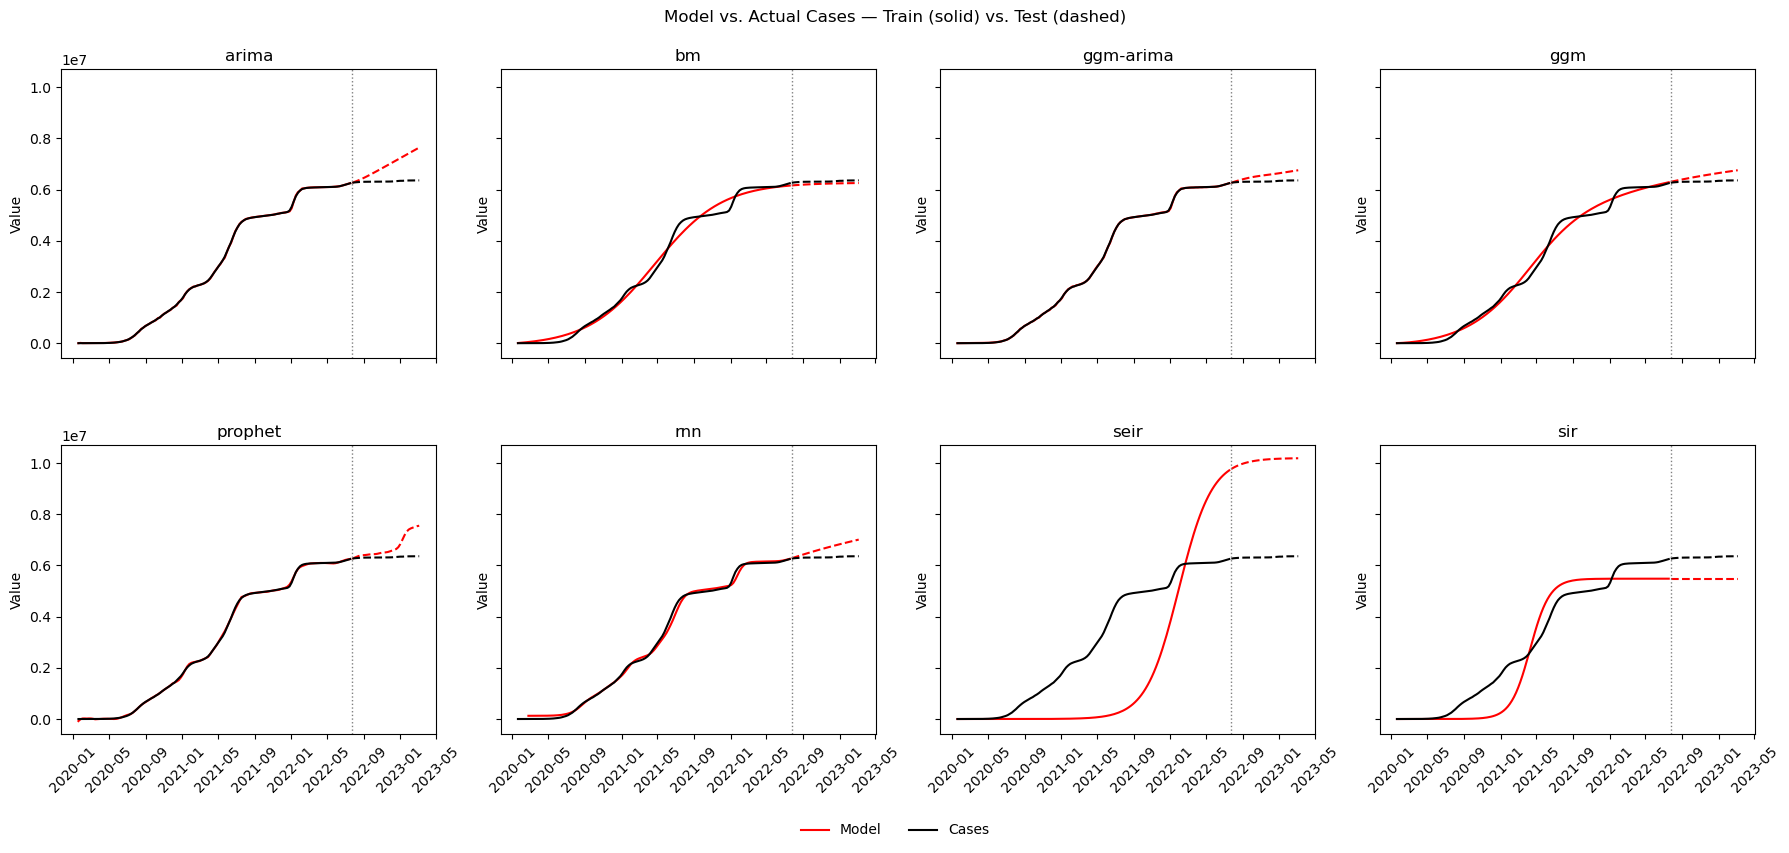

In [111]:
file_name = 'covid_colombia_train_test'
# ------------------------------------------------------------------
# 1.  Split into train / test & choose the 8 model columns
# ------------------------------------------------------------------
y_cols   = df_col.columns[3:]                     # 9 model columns 
train_df = df_col[df_col['set'] == 'train']
test_df  = df_col[df_col['set'] == 'test']

split_date = test_df['date'].min()               # first test date → vertical line

# ------------------------------------------------------------------
# 2.  2 × 4 grid
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, (ax, col) in enumerate(zip(axes, y_cols)):
    # --------------------------------------------------------------
    # Model predictions : red
    # --------------------------------------------------------------
    lbl_model = 'Model' if i == 0 else None
    ax.plot(train_df['date'], train_df[col],  color='red', label=lbl_model)
    ax.plot(test_df['date'],  test_df[col],   color='red', linestyle='--')

    # --------------------------------------------------------------
    # Actual cases       : black
    # --------------------------------------------------------------
    lbl_cases = 'Cases' if i == 0 else None
    ax.plot(train_df['date'], train_df['cases'], color='black', label=lbl_cases)
    ax.plot(test_df['date'],  test_df['cases'],  color='black', linestyle='--')

    # vertical separator
    ax.axvline(split_date, color='grey', linestyle=':', lw=1)

    ax.set_title(col)
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=45)

# ------------------------------------------------------------------
# 3.  Shared legend (labels defined only in first subplot)
# ------------------------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center',
           ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.tight_layout(rect=[0, 0.03, 1, 1])   # leave space below for legend
fig.suptitle('Model vs. Actual Cases — Train (solid) vs. Test (dashed)', y=1.03)
plt.subplots_adjust(hspace=0.3)  # space between rows
# save figure in output_dir as pdf
plt.savefig(f'{output_dir}{file_name}.pdf', bbox_inches='tight')
plt.show()

## Epidemics

In [112]:
epidemics_files

['../results\\ARIMA_epidemics.csv',
 '../results\\BM_epidemics.csv',
 '../results\\DNN_epidemics.csv',
 '../results\\ElasticNet_epidemics.csv',
 '../results\\GB_epidemics.csv',
 '../results\\GGM-ARIMA_epidemics.csv',
 '../results\\GGM_epidemics.csv',
 '../results\\Lasso_epidemics.csv',
 '../results\\OLS_epidemics.csv',
 '../results\\Prophet_epidemics.csv',
 '../results\\RF_epidemics.csv',
 '../results\\Ridge_epidemics.csv',
 '../results\\RNN_epidemics.csv',
 '../results\\SEIR_epidemics.csv',
 '../results\\SIR_epidemics.csv',
 '../results\\SVM_epidemics.csv']

In [113]:
# files you want to exclude
drop_these = {
    '../results\\OLS_epidemics.csv',
    '../results\\Lasso_epidemics.csv',
    '../results\\Ridge_epidemics.csv',
    '../results\\RidgeCV_epidemics.csv',
    '../results\\ElasticNet_epidemics.csv',
    '../results\\SVM_epidemics.csv',
    '../results\\GB_epidemics.csv',
    '../results\\RF_epidemics.csv',
    '../results\\DNN_epidemics.csv',
}

# keep everything that is *not* in drop_these
epidemics_files_ts = [f for f in epidemics_files if f not in drop_these]

epidemics_files_ts

['../results\\ARIMA_epidemics.csv',
 '../results\\BM_epidemics.csv',
 '../results\\GGM-ARIMA_epidemics.csv',
 '../results\\GGM_epidemics.csv',
 '../results\\Prophet_epidemics.csv',
 '../results\\RNN_epidemics.csv',
 '../results\\SEIR_epidemics.csv',
 '../results\\SIR_epidemics.csv']

### Dengue

In [114]:
df_dengue = df_epidemics[['date', 'dengue', 'dengue_split']].copy()
df_dengue.rename(columns={'dengue_split': 'set'}, inplace=True)
df_dengue['date'] = pd.to_datetime(df_dengue['date'])
df_dengue

,date,dengue,set
0,2007-01-01,315,train
1,2007-01-08,551,train
2,2007-01-15,803,train
3,2007-01-22,1108,train
4,2007-01-29,1468,train
...,...,...,...
890,2023-11-27,663526,test
891,2023-12-04,666895,test
892,2023-12-11,670341,test
893,2023-12-18,673653,test


In [115]:
# read covid_files_ts in a loop and append the column Colombia to df_col, change name to model
'''for file in epidemics_files_ts:
    print('processing file: ', file)
    model = file.split('\\')[-1].split('_')[0]  # get the model name from the file name
    model  = model.lower()  # convert to lower case
    df_temp = pd.read_csv(file)
    df_temp['date'] = pd.to_datetime(df_temp['date'])
    df_temp_d = df_temp.iloc[:, :2]  # get only the first two columns
    df_temp_d.columns = ['date', model]
    #print(df_temp_d.head(2))
    
    print(file,'has len: ',len(df_temp_d))
    df_dengue = pd.concat([df_col, df_temp_d], axis=1)'''

"for file in epidemics_files_ts:\n    print('processing file: ', file)\n    model = file.split('\\')[-1].split('_')[0]  # get the model name from the file name\n    model  = model.lower()  # convert to lower case\n    df_temp = pd.read_csv(file)\n    df_temp['date'] = pd.to_datetime(df_temp['date'])\n    df_temp_d = df_temp.iloc[:, :2]  # get only the first two columns\n    df_temp_d.columns = ['date', model]\n    #print(df_temp_d.head(2))\n    \n    print(file,'has len: ',len(df_temp_d))\n    df_dengue = pd.concat([df_col, df_temp_d], axis=1)"

In [116]:
df_arima_d = pd.read_csv('../results/ARIMA_epidemics.csv')
df_arima_d['date'] = pd.to_datetime(df_arima_d['date'])
df_arima_d = df_arima_d[['date', 'Dengue']]
df_arima_d.rename(columns={'Dengue': 'arima'}, inplace=True)
df_arima_d.head()


,date,arima
0,2007-01-01,314.859128
1,2007-01-08,550.894905
2,2007-01-15,787.258660
3,2007-01-22,1055.390161
4,2007-01-29,1411.422632


In [117]:
df_bm_d = pd.read_csv('../results/BM_epidemics.csv')
df_bm_d['date'] = pd.to_datetime(df_bm_d['date'])
df_bm_d = df_bm_d[['date', 'Dengue']]
df_bm_d.rename(columns={'Dengue': 'bm'}, inplace=True)
df_bm_d.head()

,date,bm
0,2007-01-01,302.977332
1,2007-01-08,607.161057
2,2007-01-15,912.554537
3,2007-01-22,1219.161131
4,2007-01-29,1526.984194


In [118]:
df_ggm_arima_d = pd.read_csv('../results/GGM-ARIMA_epidemics.csv')
df_ggm_arima_d['date'] = pd.to_datetime(df_ggm_arima_d['date'])
df_ggm_arima_d = df_ggm_arima_d[['date', 'Dengue']]
df_ggm_arima_d.rename(columns={'Dengue': 'ggm_arima'}, inplace=True)
df_ggm_arima_d.head()

,date,ggm_arima
0,2007-01-01,499.850485
1,2007-01-08,562.355295
2,2007-01-15,912.500716
3,2007-01-22,1086.769997
4,2007-01-29,1526.749869


In [119]:
df_ggm_d = pd.read_csv('../results/GGM_epidemics.csv')
df_ggm_d['date'] = pd.to_datetime(df_ggm_d['date'])
df_ggm_d = df_ggm_d[['date', 'Dengue']]
df_ggm_d.rename(columns={'Dengue': 'ggm'}, inplace=True)
df_ggm_d.head()

,date,ggm
0,2007-01-01,27.953391
1,2007-01-08,79.136904
2,2007-01-15,145.516986
3,2007-01-22,224.242392
4,2007-01-29,313.672778


In [120]:
df_prophet_d = pd.read_csv('../results/Prophet_epidemics.csv')
df_prophet_d['date'] = pd.to_datetime(df_prophet_d['date'])
df_prophet_d = df_prophet_d[['date', 'Dengue']]
df_prophet_d.rename(columns={'Dengue': 'prophet'}, inplace=True)
df_prophet_d.head()

,date,prophet
0,2007-01-01,-999.492237
1,2007-01-08,-615.110023
2,2007-01-15,-201.506938
3,2007-01-22,278.682162
4,2007-01-29,805.598525


In [121]:
df_rnn_d = pd.read_csv('../results/RNN_epidemics.csv')
df_rnn_d['date'] = pd.to_datetime(df_rnn_d['date'])
df_rnn_d = df_rnn_d[['date', 'Dengue']]
df_rnn_d.rename(columns={'Dengue': 'rnn'}, inplace=True)
df_rnn_d.head()

,date,rnn
0,2007-01-01,NaN
1,2007-01-08,NaN
2,2007-01-15,NaN
3,2007-01-22,NaN
4,2007-01-29,NaN


In [122]:
df_seir_d = pd.read_csv('../results/SEIR_epidemics.csv')
df_seir_d['date'] = pd.to_datetime(df_seir_d['date'])
df_seir_d = df_seir_d[['date', 'dengue_no_split']]
df_seir_d.rename(columns={'dengue_no_split': 'seir'}, inplace=True)
df_seir_d.head()

,date,seir
0,2007-01-01,945.000000
1,2007-01-08,1624.050590
2,2007-01-15,1997.940927
3,2007-01-22,2372.782641
4,2007-01-29,2748.577049


In [123]:
df_sir_d = pd.read_csv('../results/SIR_epidemics.csv')
df_sir_d['date'] = pd.to_datetime(df_sir_d['date'])
df_sir_d = df_sir_d[['date', 'dengue_no_split']]
df_sir_d.rename(columns={'dengue_no_split': 'sir'}, inplace=True)
df_sir_d.head()

,date,sir
0,2007-01-01,315.000000
1,2007-01-08,598.578594
2,2007-01-15,883.411668
3,2007-01-22,1169.503309
4,2007-01-29,1456.857605


In [124]:
df_dengue.head()

,date,dengue,set
0,2007-01-01,315,train
1,2007-01-08,551,train
2,2007-01-15,803,train
3,2007-01-22,1108,train
4,2007-01-29,1468,train


In [125]:
# merge all dataframes on date
df_dengue = pd.merge(df_dengue, df_arima_d, on='date', how='outer')
df_dengue = pd.merge(df_dengue, df_bm_d, on='date', how='outer')
df_dengue = pd.merge(df_dengue, df_ggm_arima_d, on='date', how='outer')
df_dengue = pd.merge(df_dengue, df_ggm_d, on='date', how='outer')
df_dengue = pd.merge(df_dengue, df_prophet_d, on='date', how='outer')
df_dengue = pd.merge(df_dengue, df_rnn_d, on='date', how='outer')
df_dengue = pd.merge(df_dengue, df_seir_d, on='date', how='outer')
df_dengue = pd.merge(df_dengue, df_sir_d, on='date', how='outer')
df_dengue = df_dengue.sort_values('date')

In [126]:
df_dengue

,date,dengue,set,arima,bm,ggm_arima,ggm,prophet,rnn,seir,sir
0,2007-01-01,315.0,train,314.859128,302.977332,499.850485,27.953391,-999.492237,NaN,945.000000,315.000000
1,2007-01-08,551.0,train,550.894905,607.161057,562.355295,79.136904,-615.110023,NaN,1624.050590,598.578594
2,2007-01-15,803.0,train,787.258660,912.554537,912.500716,145.516986,-201.506938,NaN,1997.940927,883.411668
3,2007-01-22,1108.0,train,1055.390161,1219.161131,1086.769997,224.242392,278.682162,NaN,2372.782641,1169.503309
4,2007-01-29,1468.0,train,1411.422632,1526.984194,1526.749869,313.672778,805.598525,NaN,2748.577049,1456.857605
...,...,...,...,...,...,...,...,...,...,...,...
34672,2023-11-27,663526.0,test,532068.080700,519924.213832,580772.978600,582173.721466,652179.453794,728526.8750,574693.748100,507327.135234
34673,2023-12-04,666895.0,test,532334.024600,520197.688198,581463.643400,582868.455910,653018.910028,730865.3125,575237.905400,507552.402139
34674,2023-12-11,670341.0,test,532599.968500,520470.045835,582154.378200,583563.260748,653980.574694,733228.6875,575781.006700,507776.627719
34675,2023-12-18,673653.0,test,532865.912400,520741.290155,582845.183900,584258.136965,655058.501506,735617.5000,576323.051800,507999.815910


In [127]:
df_dengue = df_dengue[['date', 'set', 'dengue', 'arima', 'bm', 'ggm_arima', 'ggm', 'prophet',
       'rnn', 'seir', 'sir']]
df_dengue.rename(columns = {'dengue': 'cases'}, inplace=True)

In [128]:
output_dir = '../latex_plots/'

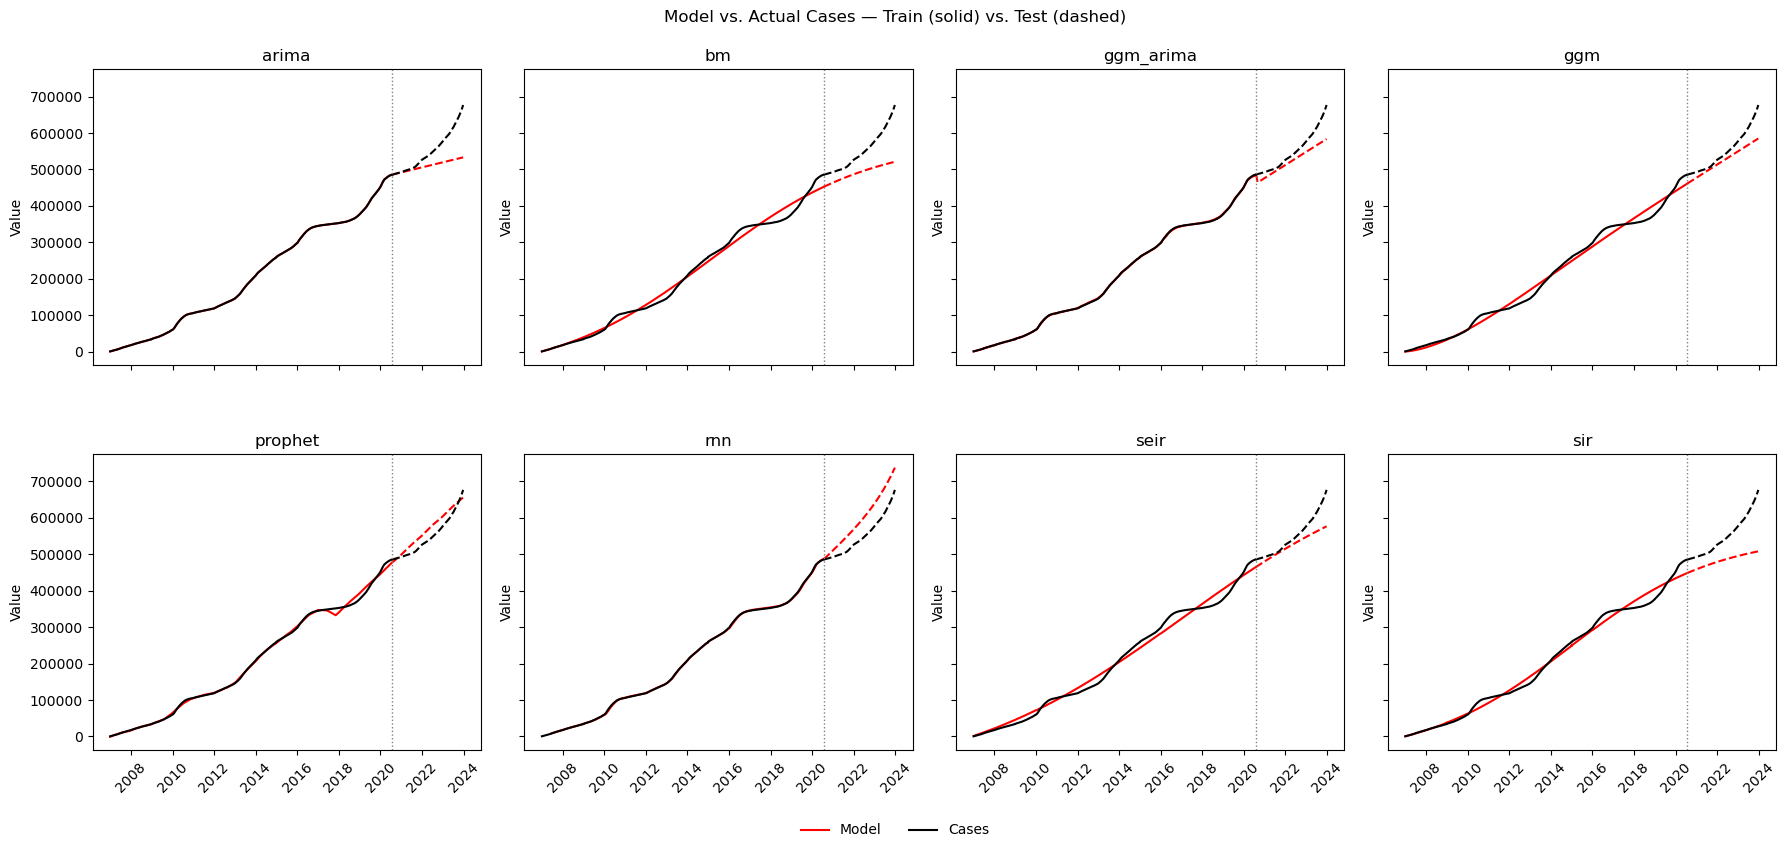

In [129]:
file_name = 'dengue_train_test'
# ------------------------------------------------------------------
# 1.  Split into train / test & choose the 8 model columns
# ------------------------------------------------------------------
y_cols   = df_dengue.columns[3:]                     # 9 model columns 
train_df = df_dengue[df_dengue['set'] == 'train']
test_df  = df_dengue[df_dengue['set'] == 'test']
split_date = test_df['date'].min()               # first test date → vertical line


# ------------------------------------------------------------------
# 2.  2 × 4 grid
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, (ax, col) in enumerate(zip(axes, y_cols)):
    # --------------------------------------------------------------
    # Model predictions : red
    # --------------------------------------------------------------
    lbl_model = 'Model' if i == 0 else None
    ax.plot(train_df['date'], train_df[col],  color='red', label=lbl_model)
    ax.plot(test_df['date'],  test_df[col],   color='red', linestyle='--')

    # --------------------------------------------------------------
    # Actual cases       : black
    # --------------------------------------------------------------
    lbl_cases = 'Cases' if i == 0 else None
    ax.plot(train_df['date'], train_df['cases'], color='black', label=lbl_cases)
    ax.plot(test_df['date'],  test_df['cases'],  color='black', linestyle='--')

    # vertical separator
    ax.axvline(split_date, color='grey', linestyle=':', lw=1)

    ax.set_title(col)
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=45)

# ------------------------------------------------------------------
# 3.  Shared legend (labels defined only in first subplot)
# ------------------------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center',
           ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.tight_layout(rect=[0, 0.03, 1, 1])   # leave space below for legend
fig.suptitle('Model vs. Actual Cases — Train (solid) vs. Test (dashed)', y=1.03)
plt.subplots_adjust(hspace=0.3)  # space between rows
# save the figure as pdf in the output_dir
fig.savefig(output_dir + file_name + '.pdf', bbox_inches='tight')
plt.show()

# Metrics

In [130]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Covid

In [131]:
df_base = pd.DataFrame()

In [132]:
# read covid_files_ts in a loop and append the column Colombia to df_col, change name to model
for file in covid_files_ts:
    print('processing file: ', file)
    model = file.split('\\')[-1].split('_')[0]  # get the model name from the file name
    model  = model.lower()  # convert to lower case
    df_temp = pd.read_csv(file)
    df_temp['date'] = pd.to_datetime(df_temp['date'])
    df_temp_long = df_temp.melt(id_vars=['date'], var_name='country', value_name='value')
    df_temp_long['model'] = model
    df_base = pd.concat([df_base, df_temp_long], axis=0)
    

processing file:  ../results\ARIMA_covid.csv
processing file:  ../results\BM_covid.csv
processing file:  ../results\GGM-Arima_covid.csv
processing file:  ../results\GGM_covid.csv
processing file:  ../results\Prophet_covid.csv
processing file:  ../results\RNN_covid.csv
processing file:  ../results\SEIR_covid.csv
processing file:  ../results\SIR_covid.csv


In [133]:
df_covid_temp = df_covid[['date', 'country', 'cases']].copy()
df_covid_temp['date'] = pd.to_datetime(df_covid_temp['date'])

### Ranking of RMSE

In [134]:
countries = df_base['country'].unique()
models = df_base['model'].unique()
n_countries = len(countries)
n_models = len(models)
rmse_matrix = np.zeros((n_countries, n_models))
r2_matrix = np.zeros((n_countries, n_models))

In [135]:
# loop over countries
for i in range(n_countries):
    country = countries[i] # set the country
    df_country = df_covid_temp[df_covid_temp['country'] == country].copy() # get the data for the country
    df_country.reset_index(drop=True, inplace=True) # reset the index
    y_true = df_country[(df_country['country'] == country)]['cases'] # get the true values
    split_point = int(len(y_true) * 0.8)        # row where the 80/20 cut happens
    y_test_true = y_true[split_point:] # get the test values
    # loop over models
    for j in range(n_models):
        
        model = models[j] # set the model
        # get the test data for the country i and model j
        df_fitted_temp = df_base[(df_base['country'] == country) & (df_base['model'] == model)].copy() # get the data for the country and model
        df_fitted_temp.reset_index(drop=True, inplace=True)
        y_pred = df_fitted_temp['value']
        y_pred_test = y_pred[split_point:]
        
        # calculate the metrics
        rmse = np.sqrt(mean_squared_error(y_test_true, y_pred_test))
        r2 = r2_score(y_test_true, y_pred_test)
        rmse_matrix[i,j] = rmse
        r2_matrix[i,j] = r2
        
# create a dataframe with the metrics
df_rmse = pd.DataFrame(rmse_matrix, columns=models, index=countries)
df_r2 = pd.DataFrame(r2_matrix, columns=models, index=countries)

In [136]:
df_rmse_t = df_rmse.transpose()
df_r2_t = df_r2.transpose()
# create mean columns
#df_rmse_t['mean'] = df_rmse_t.mean(axis=1)
#df_r2_t['mean'] = df_r2_t.mean(axis=1)

In [137]:
ranks_rmse = {}
for country in df_rmse_t.columns:
    ranks_rmse[country] = df_rmse_t[country].rank(ascending=True, method='min')

In [138]:
# ranks_rmse to dataframe
df_ranks_rmse = pd.DataFrame(ranks_rmse)
df_ranks_rmse['mean'] = df_ranks_rmse.mean(axis=1) # mean of the ranks
df_ranks_rmse

,Brazil,Chile,Colombia,Dominican Republic,Germany,Italy,Mexico,Panama,US,Uruguay,mean
arima,4.0,1.0,6.0,2.0,6.0,1.0,7.0,2.0,1.0,1.0,3.1
bm,1.0,5.0,1.0,4.0,7.0,8.0,2.0,6.0,5.0,4.0,4.3
ggm-arima,5.0,7.0,3.0,5.0,1.0,4.0,4.0,3.0,4.0,7.0,4.3
ggm,6.0,8.0,2.0,3.0,2.0,7.0,1.0,7.0,2.0,8.0,4.6
prophet,3.0,2.0,5.0,6.0,8.0,5.0,5.0,4.0,6.0,6.0,5.0
rnn,2.0,4.0,4.0,1.0,5.0,3.0,3.0,1.0,3.0,5.0,3.1
seir,8.0,3.0,8.0,8.0,3.0,2.0,8.0,5.0,7.0,2.0,5.4
sir,7.0,6.0,7.0,7.0,4.0,6.0,6.0,8.0,8.0,3.0,6.2


In [139]:
df_ranks_rmse.sort_values(by='mean', ascending=True, inplace=True)

In [140]:
output_dir = '../latex_plots/'

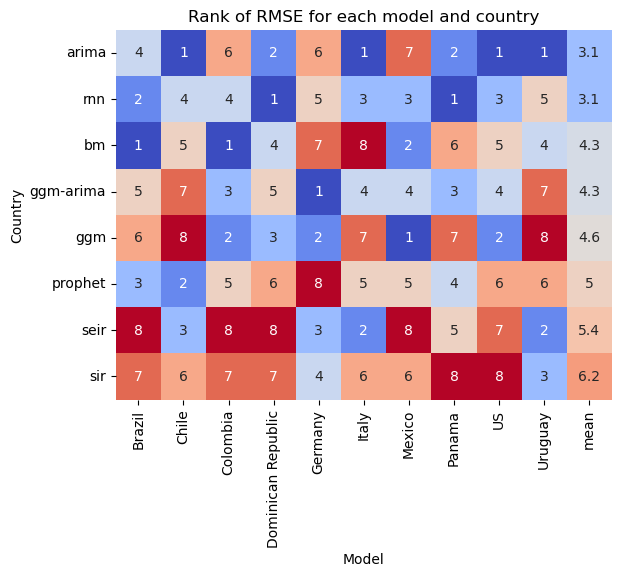

In [141]:

plot_name = 'rank_rmse_covid'
sns.heatmap(df_ranks_rmse, annot=True, cmap='coolwarm', cbar=False)
plt.title('Rank of RMSE for each model and country')
plt.xlabel('Model')
plt.ylabel('Country')
# save plot in output_dir as pdf
plt.savefig(f'{output_dir}{plot_name}.pdf', bbox_inches='tight')
plt.show()

## Epidemics

In [142]:
df_epidemics.rename(columns={'dengue': 'Dengue',
                             'zika':'Zika',
                             'chik': 'Chikungunya',
                             'var': 'Varicella'}, inplace=True)
df_epidemics.head()

,date,Dengue,Zika,Chikungunya,Varicella,dengue_split,zika_split,chik_split,var_split
0,2007-01-01,315,NaN,NaN,250.0,train,NaN,NaN,train
1,2007-01-08,551,NaN,NaN,557.0,train,NaN,NaN,train
2,2007-01-15,803,NaN,NaN,858.0,train,NaN,NaN,train
3,2007-01-22,1108,NaN,NaN,1124.0,train,NaN,NaN,train
4,2007-01-29,1468,NaN,NaN,1481.0,train,NaN,NaN,train


In [143]:
df_epidemics_temp = df_epidemics[['date', 'Dengue', 'Zika', 'Chikungunya', 'Varicella']].copy()
df_epidemics_temp['date'] = pd.to_datetime(df_epidemics_temp['date'])

In [144]:
df_epidemics_temp.head()

,date,Dengue,Zika,Chikungunya,Varicella
0,2007-01-01,315,NaN,NaN,250.0
1,2007-01-08,551,NaN,NaN,557.0
2,2007-01-15,803,NaN,NaN,858.0
3,2007-01-22,1108,NaN,NaN,1124.0
4,2007-01-29,1468,NaN,NaN,1481.0


In [145]:
file = epidemics_files_ts[0]
model = file.split('\\')[-1].split('_')[0]  # get the model name from the file name
model  = model.lower()  # convert to lower case
print(model)
df_temp = pd.read_csv(file)
df_temp['date'] = pd.to_datetime(df_temp['date'])
df_temp_long = df_temp.melt(id_vars=['date'], var_name='epidemic', value_name='value')
df_temp_long['model'] = model
df_base = pd.concat([df_base, df_temp_long], axis=0)

arima


In [146]:
df_base = pd.DataFrame()
# read covid_files_ts in a loop and append the column Colombia to df_col, change name to model
for file in epidemics_files_ts:
    print('processing file: ', file)
    model = file.split('\\')[-1].split('_')[0]  # get the model name from the file name
    model  = model.lower()  # convert to lower case
    df_temp = pd.read_csv(file)
    df_temp['date'] = pd.to_datetime(df_temp['date'])
    df_temp_long = df_temp.melt(id_vars=['date'], var_name='epidemic', value_name='value')
    df_temp_long['model'] = model
    df_base = pd.concat([df_base, df_temp_long], axis=0)

processing file:  ../results\ARIMA_epidemics.csv
processing file:  ../results\BM_epidemics.csv
processing file:  ../results\GGM-ARIMA_epidemics.csv
processing file:  ../results\GGM_epidemics.csv
processing file:  ../results\Prophet_epidemics.csv
processing file:  ../results\RNN_epidemics.csv
processing file:  ../results\SEIR_epidemics.csv
processing file:  ../results\SIR_epidemics.csv


In [147]:
df_base['epidemic'].unique()
# epidemic to lowercase
df_base['epidemic'] = df_base['epidemic'].str.lower()
df_base['epidemic'].unique()
# fix some names
df_base['epidemic'] = df_base['epidemic'].replace({'varicela': 'varicella',
                                                    'chicungunya': 'chikungunya',
                                                    'chicunguya': 'chikungunya',
                                                    'dengue_no_split': 'dengue'})
# capitalize epidemic names
df_base['epidemic'] = df_base['epidemic'].str.capitalize()
df_base['epidemic'].unique()

array(['Dengue', 'Varicella', 'Chikungunya', 'Zika'], dtype=object)

### Ranking of RMSE

In [148]:
epidemics = df_base['epidemic'].unique()
models = df_base['model'].unique()
n_epidemics = len(epidemics)
n_models = len(models)
rmse_matrix = np.zeros((n_epidemics, n_models))
r2_matrix = np.zeros((n_epidemics, n_models))

In [149]:
df_epidemics_temp.head()

,date,Dengue,Zika,Chikungunya,Varicella
0,2007-01-01,315,NaN,NaN,250.0
1,2007-01-08,551,NaN,NaN,557.0
2,2007-01-15,803,NaN,NaN,858.0
3,2007-01-22,1108,NaN,NaN,1124.0
4,2007-01-29,1468,NaN,NaN,1481.0


In [150]:
# loop over countries
for i in range(n_epidemics):
    #print('processing epidemic: ', epidemics[i])
    epidemic = epidemics[i] # set the country
    df_epidemic = df_epidemics_temp[['date', epidemic]].copy() # get the data for the epidemic
    df_epidemic.rename(columns={epidemic: 'cases'}, inplace=True)
    df_epidemic.dropna(subset='cases', inplace=True)
    df_epidemic.reset_index(drop=True, inplace=True) # reset the index
    
    # loop over models
    for j in range(n_models):
        #print('processing model: ', models[j])
        
        model = models[j] # set the model
        # get the test data for the country i and model j
        df_fitted_temp = df_base[(df_base['epidemic'] == epidemic) & (df_base['model'] == model)].copy() # get the data for the country and model
        df_fitted_temp.dropna(subset = ['value'], inplace=True)
        df_fitted_temp.reset_index(drop=True, inplace=True)
        # create a temporal df merged by date
        df_temp_merge = df_epidemic.merge(df_fitted_temp, on='date', how='outer')
        # interpolate the missing values in the value column
        df_temp_merge['value'] = df_temp_merge['value'].interpolate(method='linear')
        
        # drop the rows with missing values
        df_temp_merge.dropna(subset=['cases', 'value'], inplace=True)
        # get true and pred values
        y_true = df_temp_merge['cases'] # get the true values
        split_point = int(len(y_true) * 0.8)        # row where the 80/20 cut happens
        y_test_true = y_true[split_point:] # get the test values


        y_pred = df_temp_merge['value']
        y_pred_test = y_pred[split_point:]


        # calculate the metrics
        rmse = np.sqrt(mean_squared_error(y_test_true, y_pred_test))
        r2 = r2_score(y_test_true, y_pred_test)
        rmse_matrix[i,j] = rmse
        r2_matrix[i,j] = r2
        
# create a dataframe with the metrics
df_rmse = pd.DataFrame(rmse_matrix, columns=models, index=epidemics)
df_r2 = pd.DataFrame(r2_matrix, columns=models, index=epidemics)

In [151]:
df_rmse_t = df_rmse.transpose()
df_r2_t = df_r2.transpose()
# create mean columns
#df_rmse_t['mean'] = df_rmse_t.mean(axis=1)
#df_r2_t['mean'] = df_r2_t.mean(axis=1)

In [152]:
ranks_rmse = {}
for epidemic in df_rmse_t.columns:
    ranks_rmse[epidemic] = df_rmse_t[epidemic].rank(ascending=True, method='min')

In [153]:
# ranks_rmse to dataframe
df_ranks_rmse = pd.DataFrame(ranks_rmse)
df_ranks_rmse['mean'] = df_ranks_rmse.mean(axis=1) # mean of the ranks
df_ranks_rmse

,Dengue,Varicella,Chikungunya,Zika,mean
arima,6.0,1.0,1.0,1.0,2.25
bm,7.0,8.0,6.0,7.0,7.00
ggm-arima,2.0,3.0,3.0,2.0,2.50
ggm,3.0,4.0,4.0,5.0,4.00
prophet,1.0,6.0,2.0,8.0,4.25
rnn,5.0,7.0,8.0,4.0,6.00
seir,4.0,2.0,7.0,6.0,4.75
sir,8.0,5.0,5.0,3.0,5.25


In [154]:
df_ranks_rmse.sort_values(by='mean', ascending=True, inplace=True)

In [155]:
output_dir = '../latex_plots/'

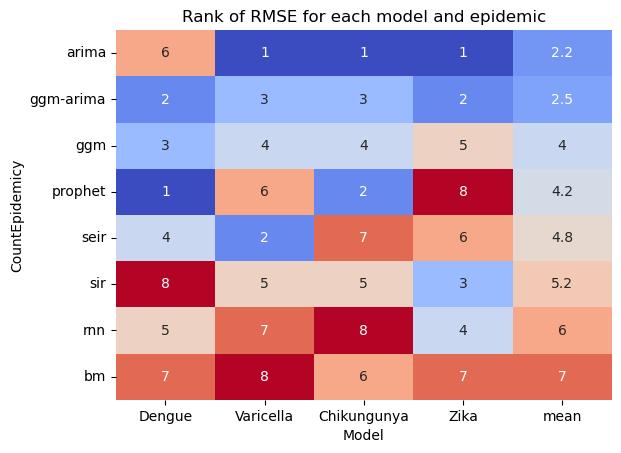

In [156]:

plot_name = 'rank_rmse_epidemics'
sns.heatmap(df_ranks_rmse, annot=True, cmap='coolwarm', cbar=False)
plt.title('Rank of RMSE for each model and epidemic')
plt.xlabel('Model')
plt.ylabel('CountEpidemicy')
# save plot in output_dir as pdf
plt.savefig(f'{output_dir}{plot_name}.pdf', bbox_inches='tight')
plt.show()